In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import glob
import re
import csv

C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um\02_FEL beam on the edge_Gr+InSb-up_InSb-down-along lines_gap-0_IMO-38_0001.ascii.csv
Sum of aperture in C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um\02_FEL beam on the edge_Gr+InSb-up_InSb-down-along lines_gap-0_IMO-38_0001.ascii.csv: 6600484.078125
C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um\03_FEL beam on the edge_Gr+InSb-up_InSb-down-along lines_gap-500_IMO-38_0001.ascii.csv
Sum of aperture in C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um\03_FEL beam on the edge_Gr+InSb-up_InSb-down-along lines_

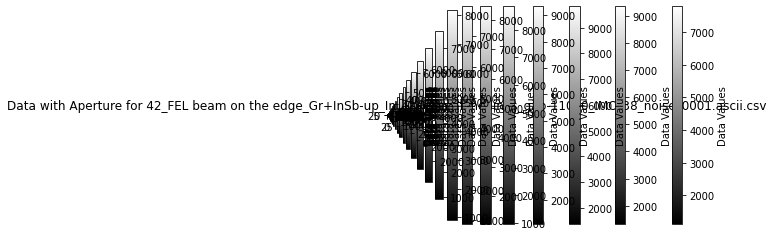

In [6]:
# Helper function to extract numeric part from a filename 
def extract_numeric(filename):
    # Use regular expression to find all numeric parts in the filename
    numbers = re.findall(r'\d+', os.path.basename(filename))
    # Convert the list of found numbers to integers and return
    return int(numbers[0]) 

# Conversion of coordinates
def convert_coords(pixel_coords):
    x_pos, width, y_pos, height = pixel_coords
    x1 = (x_pos-width//2) // 80
    y1 = (25600 - y_pos - height//2) // 80
    x2 = (x_pos + width//2) // 80
    y2 = (25600 - y_pos + height//2) // 80
    return (x1, y1, x2, y2)

def process_files(folder_path, ori, pixel_coords, output_file):
    # Get all ASCII files in the folder
    aperture_coords = convert_coords(pixel_coords)
    files = glob.glob(os.path.join(folder_path, '*ascii.csv'))  # Modify file extension if needed
    
    # Sort files by numeric elements extracted from the filenames
    files_sorted = sorted(files, key=extract_numeric)

    results = []
    
    for file in files_sorted:
        if 'FEL' in file and ori in file:

            # Read ASCII file with semicolon as separator and treating commas as decimal points
            print(file)
            df = pd.read_csv(file, sep=';', decimal=',', header=None)
        
            # Convert the DataFrame to a NumPy array for easier slicing and summing
            data = df.to_numpy()
        
            # Aperture coordinates (assumed in the format (x1, y1, x2, y2))
            x1, y1, x2, y2 = aperture_coords
        
            # Summing values within the rectangular aperture
            aperture_sum = np.sum(data[y1:y2, x1:x2])
        
            print(f"Sum of aperture in {file}: {aperture_sum}") 
        
            # Visualizing the aperture
            aperture_data = data[y1:y2, x1:x2]
            plt.imshow(aperture_data, cmap='gray', interpolation='none')
            plt.colorbar(label='Data Values')
        
            # Marking the aperture
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='red', facecolor='none', lw=2))
            plt.title(f"Data with Aperture for {os.path.basename(file)}")
            #plt.show()

            # Append the result (filename, aperture_sum)
            results.append([os.path.basename(file), aperture_sum])
    
    # Create a DataFrame and save it to the output file  
    results_df = pd.DataFrame(results, columns=['Filename', 'Aperture Sum'])
    results_df.to_csv(os.path.join(folder_path, output_file), sep=';', decimal=',', index=False, quoting=csv.QUOTE_MINIMAL, encoding='utf-8-sig')   

# Example usage:
folder_path = r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um'
pixel_coords = (13946, 3403, 14016, 2413)  # Example aperture coordinates (x1, y1, x2, y2)

process_files(folder_path, 'along', pixel_coords, 'output_along_12_In.ascii')